# Taller 2. Transformada de Fourier


In [ ]:
# @title Librerias
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from scipy import signal
from PIL import Image

### Fenómeno de Gibbs


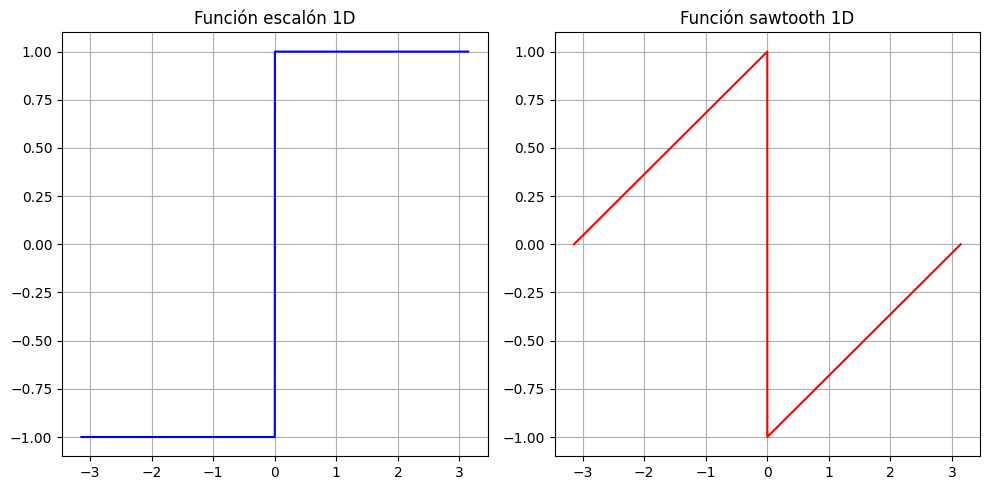

In [ ]:
# @title Genera la funcion escalon 1D y la funcion sawtooth 1D, entre [-pi, pi], con resolucion 1e-4.
# Parametros de la funcion
res = 1e-4
x = np.arange(-np.pi, np.pi, res)

# Funcion Escalon
fun_esc = np.where(x > 0, 1, -1)

# Funcion Diente de Sierra
fun_sie = signal.sawtooth(x)

# Grafica
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, fun_esc, color='blue')
plt.title("Función escalón 1D")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x, fun_sie, color='red')
plt.title("Función sawtooth 1D")
plt.grid(True)

plt.tight_layout()
plt.savefig('Fun_Esc_Saw.png', dpi=300)
plt.show()

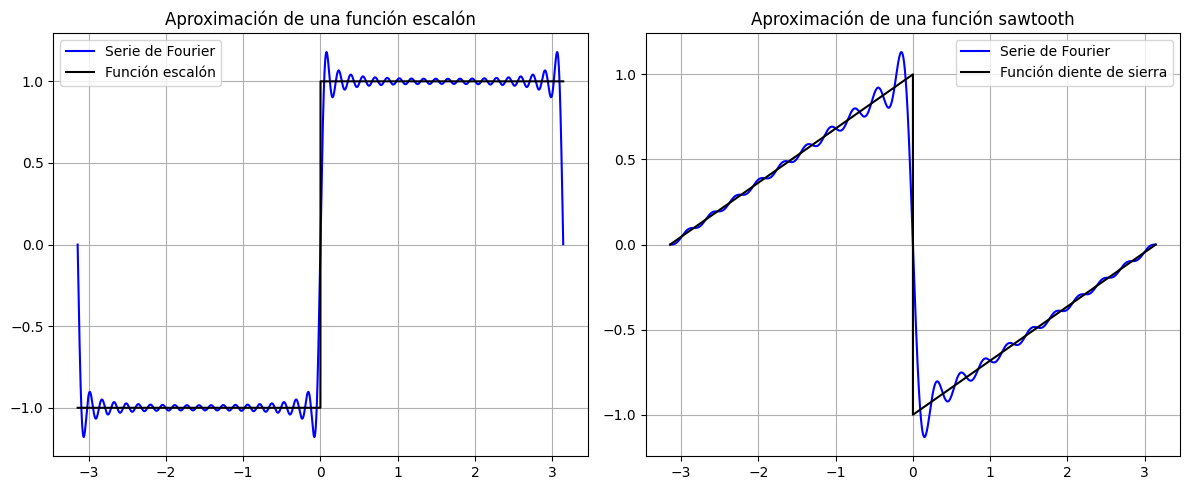

In [ ]:
# @title Representa cada una de ellas como una serie de Fourier, aumentando el número de términos utilizados en la aproximación de 1 hasta 20000.
# Variables
y_escalon = np.zeros(x.shape[0])
y_sierra = np.zeros(x.shape[0])

for i in range(1, 21, 1):
  # Funcion rectangular
  y_escalon += (4/np.pi) * (1/(2*i-1)) * np.sin((2*i-1)*x)

  #funcion Sierra
  y_sierra += (-2/np.pi) * (1/i) * np.sin(i*x)

# Grafica
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x, y_escalon, color='blue', label='Serie de Fourier')
plt.plot(x, fun_esc, color='black', label='Función escalón')
plt.title("Aproximación de una función escalón")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x, y_sierra, color='blue', label='Serie de Fourier')
plt.plot(x, fun_sie, color='black', label='Función diente de sierra')
plt.title("Aproximación de una función sawtooth")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('Fun_Esc_Saw.png', dpi=300)
plt.show()

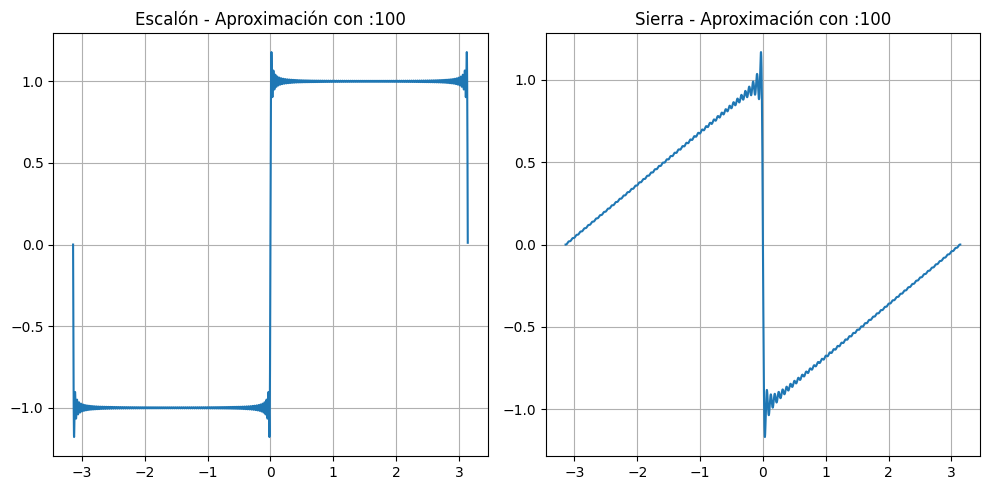

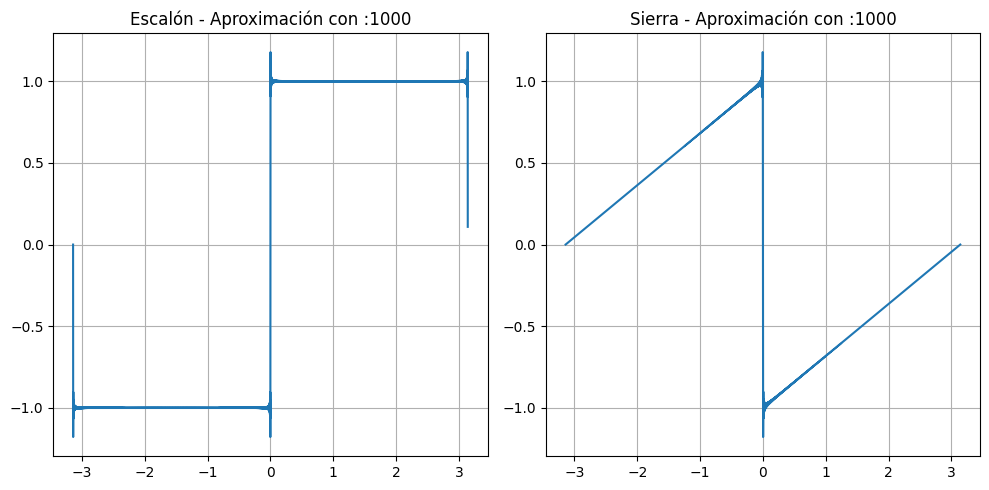

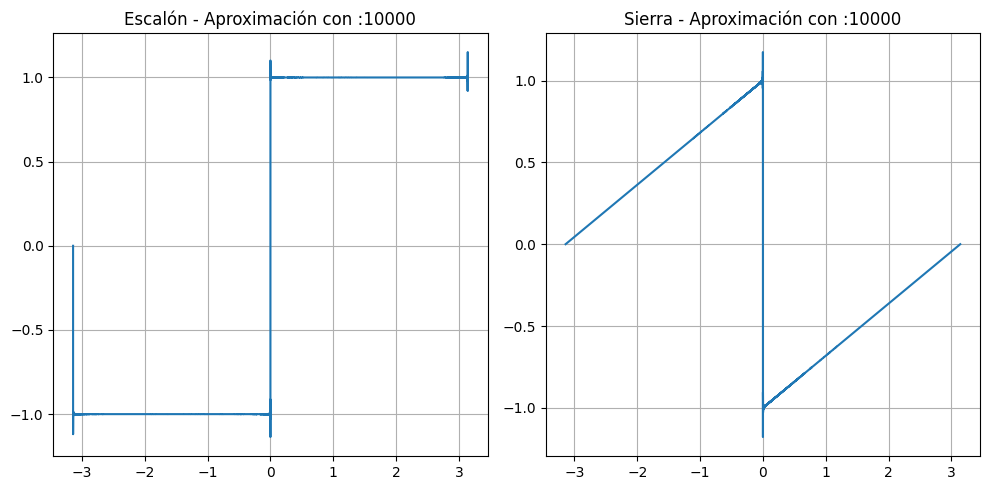

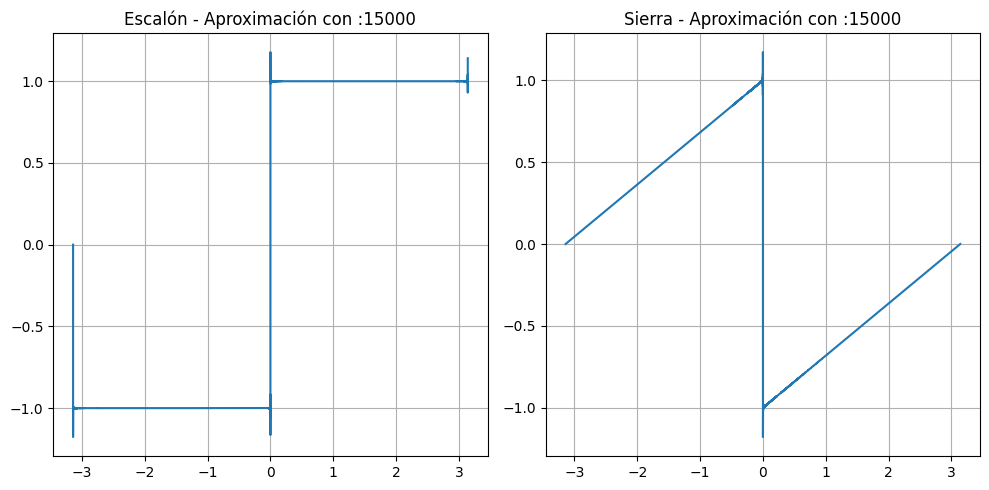

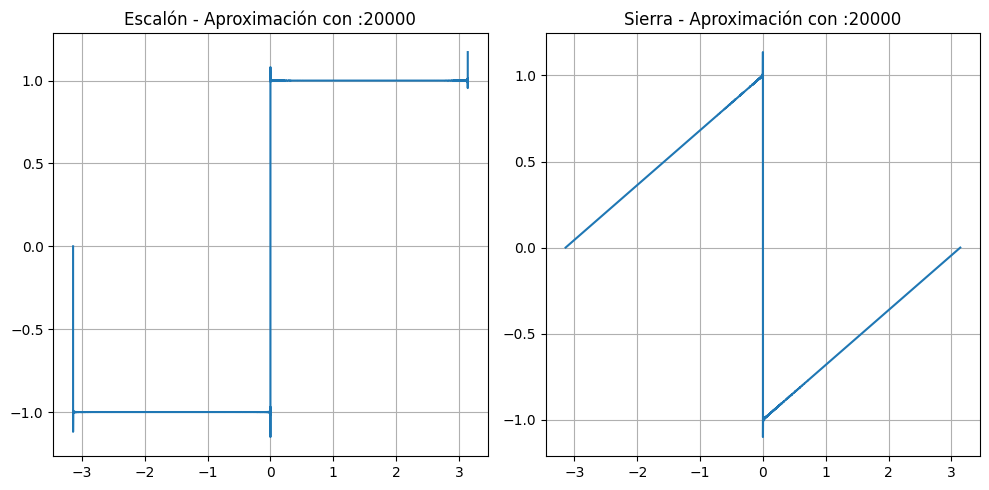

In [ ]:
# @title Haz una gráfica de la aproximación y analiza cómo se comporta en las discontinuidades a medida que aumentamos el número de términos de la aproximación.
# Variables
y_escalon = np.zeros(x.shape[0])
y_sierra = np.zeros(x.shape[0])

# Valores de N que vamos a visualizar.
n = [100, 1000, 10000, 15000, 20000]

# Índice para recorrer
idx = 0

# Grafica
for i in range(1, 20001, 1):
  # Funcion rectangular
  y_escalon += (4/np.pi) * (1/(2*i-1)) * np.sin((2*i-1)*x)

  #funcion Sierra
  y_sierra += (-2/np.pi) * (1/i) * np.sin(i*x)

  # Grafica
  if i == n[idx]:
    plt.figure(figsize=(10, 5))

    # Escalón
    plt.subplot(1,2,1)
    plt.plot(x, y_escalon)
    plt.title(f'Escalón - Aproximación con :{i}')
    plt.grid()

    # Sierra
    plt.subplot(1,2,2)
    plt.plot(x, y_sierra)
    plt.title(f'Sierra - Aproximación con :{i}')
    plt.grid()

    plt.tight_layout()
    plt.savefig(f'Aprox_Fourier_N_{i}.png', dpi=300)
    plt.show()

    idx += 1

    if idx >= len(n):
      break

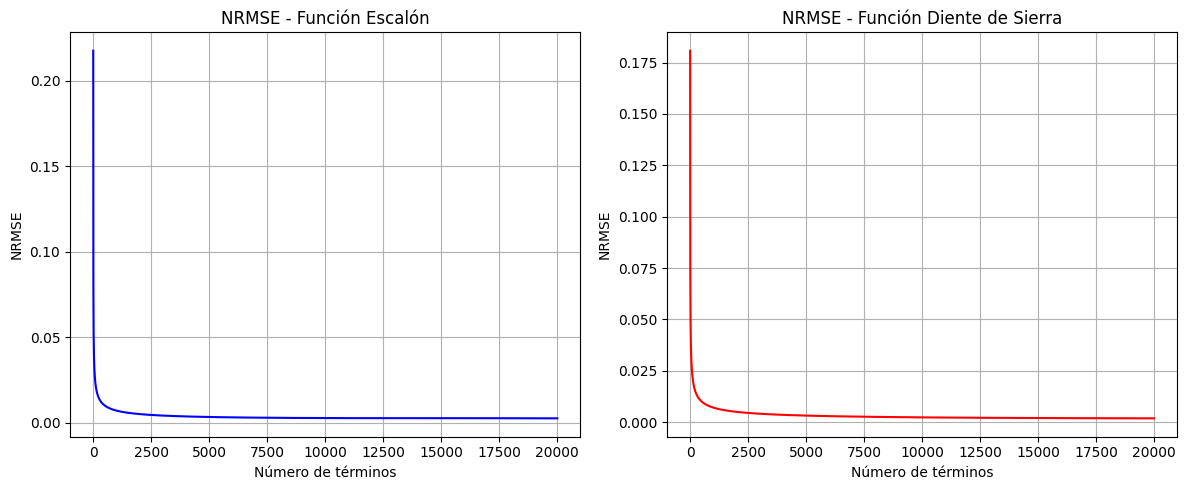

In [ ]:
# @title Haz una gráfica del error de la aproximación en términos de NRMSE (Normalized Root Mean Squared Error) contra el número de términos utilizados.
# Variables
y_escalon = np.zeros(x.shape[0])
y_sierra = np.zeros(x.shape[0])

nrmse_escalon = []
nrmse_sierra = []

limite_terminos = 20000
n = np.arange(1, 20001)

for i in range(1, 20001):
    # Función escalon
    y_escalon += (4/np.pi) * (1/(2*i-1)) * np.sin((2*i-1)*x)
    rmse_e = np.sqrt(np.mean((fun_esc - y_escalon)**2))
    nrmse_e = rmse_e / (fun_esc.max() - fun_esc.min())
    nrmse_escalon.append(nrmse_e)

    # Función Sierra
    y_sierra += (-2/np.pi) * (1/i) * np.sin(i * x)
    rmse_s = np.sqrt(np.mean((fun_sie - y_sierra)**2))
    nrmse_s = rmse_s / (fun_sie.max() - fun_sie.min())
    nrmse_sierra.append(nrmse_s)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(n, nrmse_escalon, color='blue')
plt.title("NRMSE - Función Escalón")
plt.xlabel("Número de términos")
plt.ylabel("NRMSE")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(n, nrmse_sierra, color='red')
plt.title("NRMSE - Función Diente de Sierra")
plt.xlabel("Número de términos")
plt.ylabel("NRMSE")
plt.grid(True)

plt.tight_layout()
plt.savefig('Error_Esc_Saw.png', dpi=300)
plt.show()


In [ ]:
# @title ¿Cuál es el mínimo error obtenido de la aproximación para cada función?
# Error minimo escalon
min_error_escalon = min(nrmse_escalon)

# Error minimo sierra
min_error_sierra = min(nrmse_sierra)

print("Minimo NRMSE Escalon:", min_error_escalon)
print("Minimo NRMSE Sierra:", min_error_sierra)

Minimo NRMSE Escalon: 0.002646311335988336
Minimo NRMSE Sierra: 0.0018885145407252534


In [ ]:
# @title ¿Cuántos términos son necesarios para alcanzar el 5\%?
ind_escalon = np.where(np.array(nrmse_escalon) <= 0.05)[0]
ind_sierra = np.where(np.array(nrmse_sierra) <= 0.05)[0]

print("Escalon:")
print("Ocurre en N =", ind_escalon)

print("\nSierra:")
print("Ocurre en N =", ind_sierra)

Escalon:
Ocurre en N = [   20    21    22 ... 19997 19998 19999]

Sierra:
Ocurre en N = [   19    20    21 ... 19997 19998 19999]


In [ ]:
# @title ¿Cuántos términos son necesarios para alcanzar el 1\%?
# @title ¿Cuántos términos son necesarios para alcanzar el 5\%?
ind_escalon = np.where(np.array(nrmse_escalon) <= 0.01)[0]
ind_sierra = np.where(np.array(nrmse_sierra) <= 0.01)[0]

print("Escalon:")
print("Ocurre en N =", ind_escalon)

print("\nSierra:")
print("Ocurre en N =", ind_sierra)

Escalon:
Ocurre en N = [  510   511   512 ... 19997 19998 19999]

Sierra:
Ocurre en N = [  506   507   508 ... 19997 19998 19999]


In [ ]:
# @title ¿Cuántos términos son necesarios para alcanzar el mínimo NRMSE?
# Indice del minimo
idx_escalon = np.argmin(nrmse_escalon)
idx_sierra = np.argmin(nrmse_sierra)

# Numero de terminos correspondiente
N_escalon = n[idx_escalon]
N_sierra = n[idx_sierra]

print("Escalon:")
print("NRMSE minimo =", min_error_escalon)
print("Ocurre en N =", N_escalon)

print("\nSierra:")
print("NRMSE minimo =", min_error_sierra)
print("Ocurre en N =", N_sierra)

Escalon:
NRMSE minimo = 0.002646311335988336
Ocurre en N = 20000

Sierra:
NRMSE minimo = 0.0018885145407252538
Ocurre en N = 20000


## Representado imágenes utilizando la serie de Fourier 2D

In [ ]:
# @title Connect Drive
from google.colab import drive
drive.mount('/content/drive')
%cd '/content/drive/MyDrive/Septimo/Procesamiento de imágenes digitales/Data'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Septimo/Procesamiento de imágenes digitales/Data


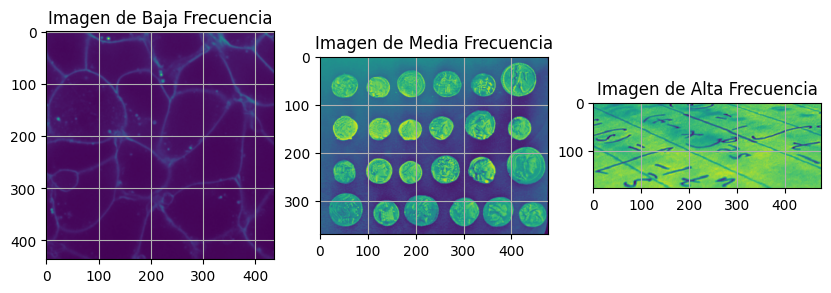

In [ ]:
# @title Leer las imaganes de mi drive y pasarlas a escalas de grises
img_baja = cv.imread('BajaFrecuencia.png', cv.IMREAD_GRAYSCALE)
img_media = cv.imread('MediaFrecuencia.png', cv.IMREAD_GRAYSCALE)
img_alta = cv.imread('AltaFrecuencia.png', cv.IMREAD_GRAYSCALE)

# Grafica
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_baja)
plt.title("Imagen de Baja Frecuencia")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.imshow(img_media)
plt.title("Imagen de Media Frecuencia")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.imshow(img_alta)
plt.title("Imagen de Alta Frecuencia")
plt.grid(True)

plt.show()

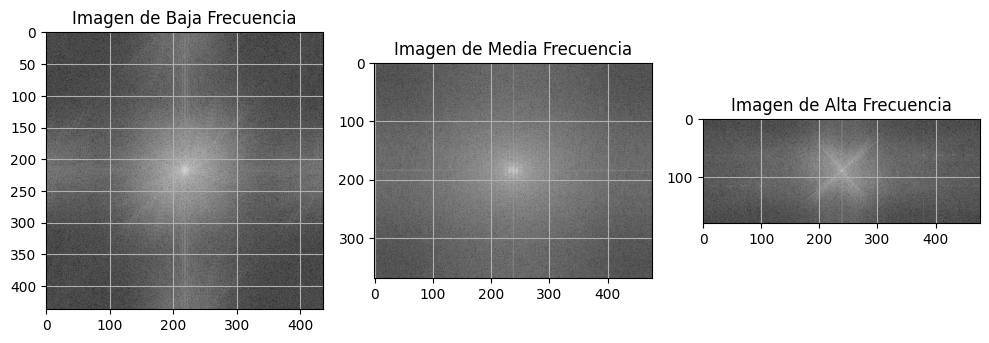

In [ ]:
# @title Para cada una de las imágenes, calcula la transformada de Fourier 2D y centrala.
# Trasformada
F_baja = np.fft.fft2(img_baja)
F_media = np.fft.fft2(img_media)
F_alta = np.fft.fft2(img_alta)

# Shift
F_Shift_baja = np.fft.fftshift(F_baja)
F_Shift_media = np.fft.fftshift(F_media)
F_Shift_alta = np.fft.fftshift(F_alta)

# Magnitud
magnitude_baja = np.log1p(np.abs(F_Shift_baja))
magnitude_media = np.log1p(np.abs(F_Shift_media))
magnitude_alta = np.log1p(np.abs(F_Shift_alta))

# Grafica
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(magnitude_baja, cmap='gray')
plt.title("Imagen de Baja Frecuencia")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.imshow(magnitude_media, cmap='gray')
plt.title("Imagen de Media Frecuencia")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.imshow(magnitude_alta, cmap='gray')
plt.title("Imagen de Alta Frecuencia")
plt.grid(True)

plt.tight_layout()
plt.savefig('Trans_Fourier.png', dpi=300)
plt.show()

#### Prueba con imagenes cuadradas

Dimesiones de las imagen de baja frecuencia:  (437, 437)
Dimesiones de las imagen de media frecuencia:  (370, 476)
Dimesiones de las imagen de Alta frecuencia:  (179, 477)
Dimesiones de las imagen de baja frecuencia (ajustada):  (437, 437)
Dimesiones de las imagen de media frecuencia (ajustada):  (370, 370)
Dimesiones de las imagen de Alta frecuencia (ajustada):  (179, 179)


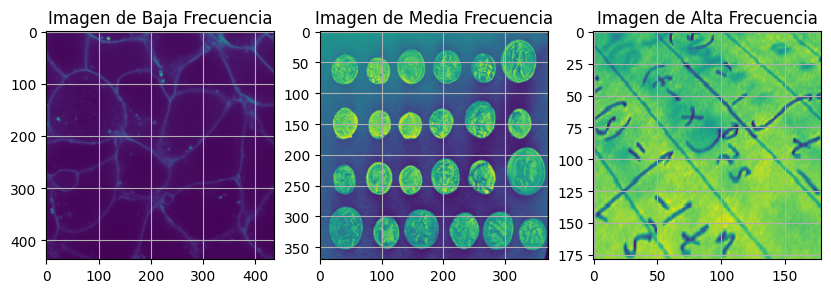

In [ ]:
# @title Ajustar el tamaño de las dimesiones para imaganes rectagulares
print('Dimesiones de las imagen de baja frecuencia: ',img_baja.shape)
print('Dimesiones de las imagen de media frecuencia: ', img_media.shape)
print('Dimesiones de las imagen de Alta frecuencia: ',img_alta.shape)

#Imaganes rectangulares
img_media = cv.resize(img_media, (370, 370))
img_alta = cv.resize(img_alta, (179, 179))

print('Dimesiones de las imagen de baja frecuencia (ajustada): ',img_baja.shape)
print('Dimesiones de las imagen de media frecuencia (ajustada): ', img_media.shape)
print('Dimesiones de las imagen de Alta frecuencia (ajustada): ',img_alta.shape)

# Grafica
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_baja)
plt.title("Imagen de Baja Frecuencia")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.imshow(img_media)
plt.title("Imagen de Media Frecuencia")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.imshow(img_alta)
plt.title("Imagen de Alta Frecuencia")
plt.grid(True)

plt.show()

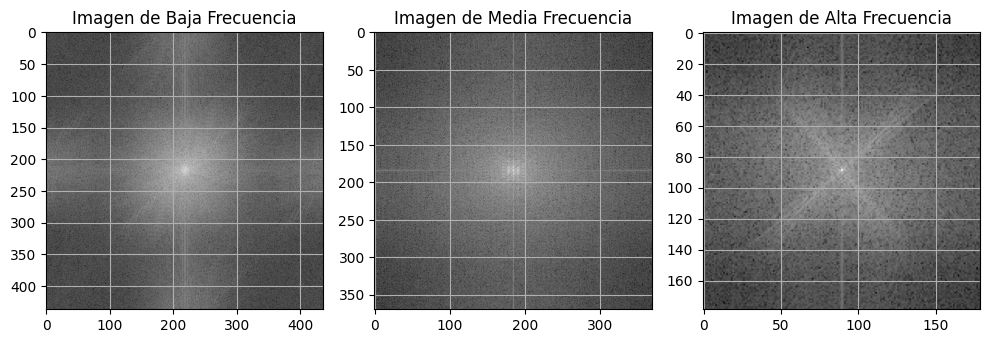

In [ ]:
# @title Transforamda de fourier 2D para las imagenes con nuevas cuadradas
# @title Para cada una de las imágenes, calcula la transformada de Fourier 2D y centrala.
# Trasformada
F_baja = np.fft.fft2(img_baja)
F_media = np.fft.fft2(img_media)
F_alta = np.fft.fft2(img_alta)

# Shift
F_Shift_baja = np.fft.fftshift(F_baja)
F_Shift_media = np.fft.fftshift(F_media)
F_Shift_alta = np.fft.fftshift(F_alta)

# Magnitud
magnitude_baja = np.log1p(np.abs(F_Shift_baja))
magnitude_media = np.log1p(np.abs(F_Shift_media))
magnitude_alta = np.log1p(np.abs(F_Shift_alta))

# Grafica
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(magnitude_baja, cmap='gray')
plt.title("Imagen de Baja Frecuencia")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.imshow(magnitude_media, cmap='gray')
plt.title("Imagen de Media Frecuencia")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.imshow(magnitude_alta, cmap='gray')
plt.title("Imagen de Alta Frecuencia")
plt.grid(True)

plt.tight_layout()
plt.savefig('Trans_Fourier.png', dpi=300)
plt.show()

### Programa una función que seleccione ordenadamente los valores de la transformada de Fourier, desde el centro (componente DC) hacia afuera, en términos de la distancia, teniendo en cuenta que las posiciones simétricas respecto al centro corresponden al par de coeficientes de frecuencia de la función coseno.

In [ ]:
# @title Funcion
def extraer_coeficientes(F_shifted):
  #Ancho y alto de la imagen
  M, N = F_shifted.shape

  #Ubicacion del componente CD
  cx, cy = M // 2, N // 2

  #Guardar distancia entre los puntos y el componente CD
  puntos = []

  for i in range(M):
    for j in range(N):
        dist = ((i - cx)**2 + (j - cy)**2) ** 0.5
        puntos.append((dist, i, j))

  #Ordenamos los puntos
  puntos.sort()

  #Guardamos los pares de puntos
  visitado = [[False] * N for _ in range(M)]
  par_puntos = []

  for dist, i, j in puntos:
    #Revisa si ya fue guardado
    if visitado[i][j]:
      continue

    #Punto simetrico respecto al componente CD
    si = 2 * cx - i
    sj = 2 * cy - j

    #Verificar si el punto esta dentro de la imagen
    simetrico_valido = (0 <= si < M) and (0 <= sj < N)

    if simetrico_valido:
      par = {
          'pos_1'  : (i, j),
          'pos_2'  : (si, sj),
          'coef_1'    : F_shifted[i, j],
          'coef_2'    : F_shifted[si, sj],
      }
      visitado[i][j]   = True
      visitado[si][sj] = True
      par_puntos.append(par)

  return par_puntos

In [ ]:
# Lista de los pares de puntos
datos_baja = extraer_coeficientes(F_Shift_baja)
datos_media = extraer_coeficientes(F_Shift_media)
datos_alta = extraer_coeficientes(F_Shift_alta)

### Para cada par de coeficientes nuevos seleccionado, debes calcular la transformada inversa de Fourier para conocer la función correspondiente y sumarla con las que lleves hasta el momento. La idea es observar cómo se va obteniendo la imagen original a medida que aumentamos el número de términos seleccionados e invertidos de la transformada de Fourier.

In [ ]:
# @title Funcion
def reconstruir_imagenes(F_shifted, par_puntos, porcentajes):
    M, N = F_shifted.shape
    total_pares = len(par_puntos)

    fig, axes = plt.subplots(1, len(porcentajes), figsize=(4 * len(porcentajes), 4))

    for idx, porcentaje in enumerate(porcentajes):
        #Pares de puntos utilizo
        n_pares = int(total_pares * porcentaje / 100)

        #Para guardar los coeficientes seleccionados
        F_parcial = np.zeros((M, N), dtype=complex)

        # Llenar solo con los primeros n_pares (los de menor distancia al DC)
        cx, cy = M // 2, N // 2
        for k in range(n_pares):
            i,  j  = par_puntos[k]['pos_1']
            si, sj = par_puntos[k]['pos_2']
            F_parcial[i,  j]  = par_puntos[k]['coef_1']
            F_parcial[si, sj] = par_puntos[k]['coef_2']

        # Revertir el fftshift antes de aplicar la inversa
        F_revertida = np.fft.ifftshift(F_parcial)

        # Transformada inversa — tomar solo la parte real
        imagen_reconstruida = np.real(np.fft.ifft2(F_revertida))

        # Visualizar
        axes[idx].imshow(imagen_reconstruida, cmap='gray')
        axes[idx].set_title(f'{porcentaje}% ({n_pares} pares)')
        axes[idx].axis('off')

    plt.suptitle('Reconstrucción progresiva desde el componente DC', y=1.02)
    plt.tight_layout()
    plt.show()

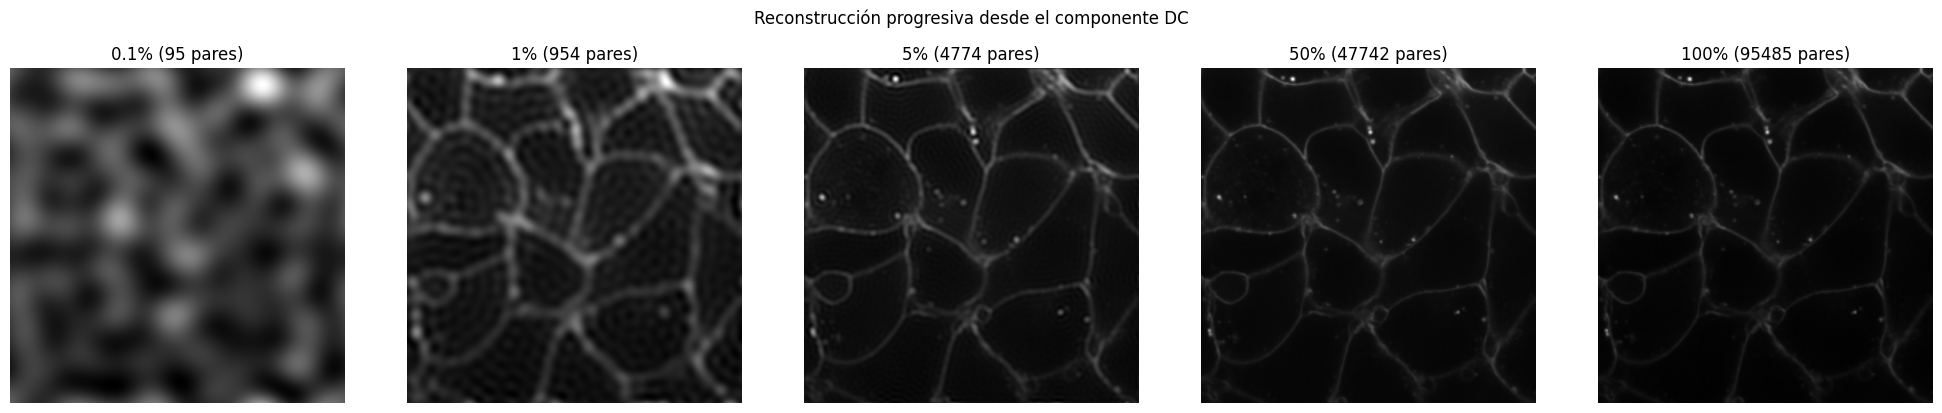

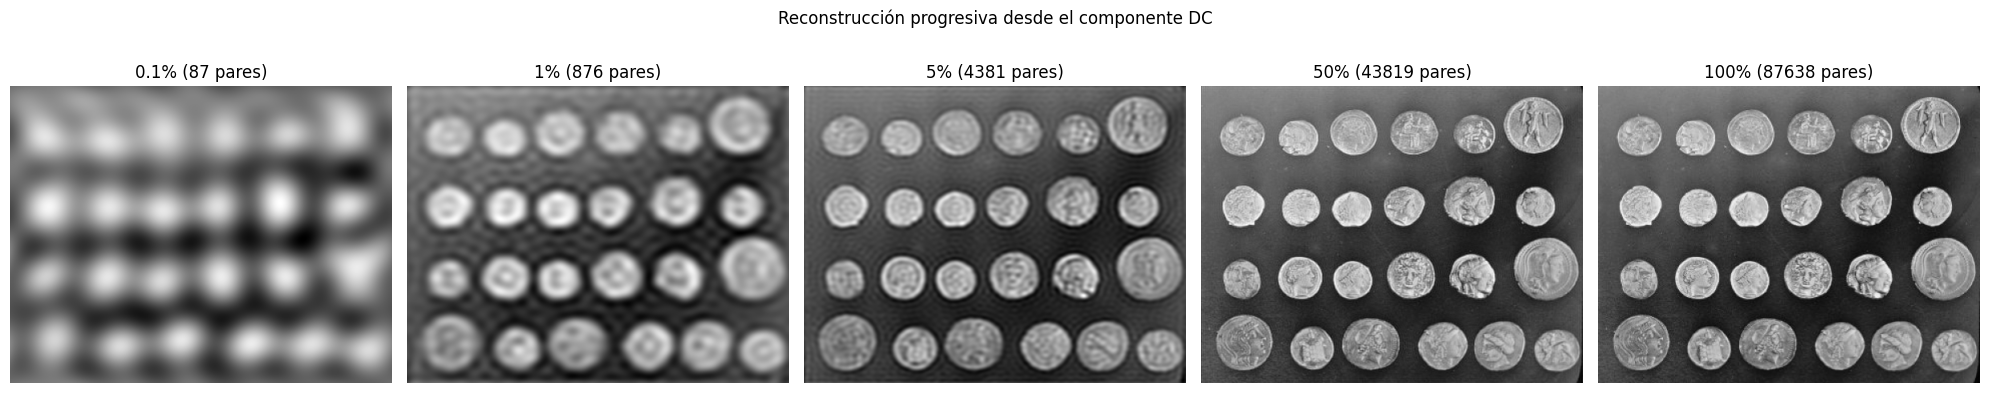

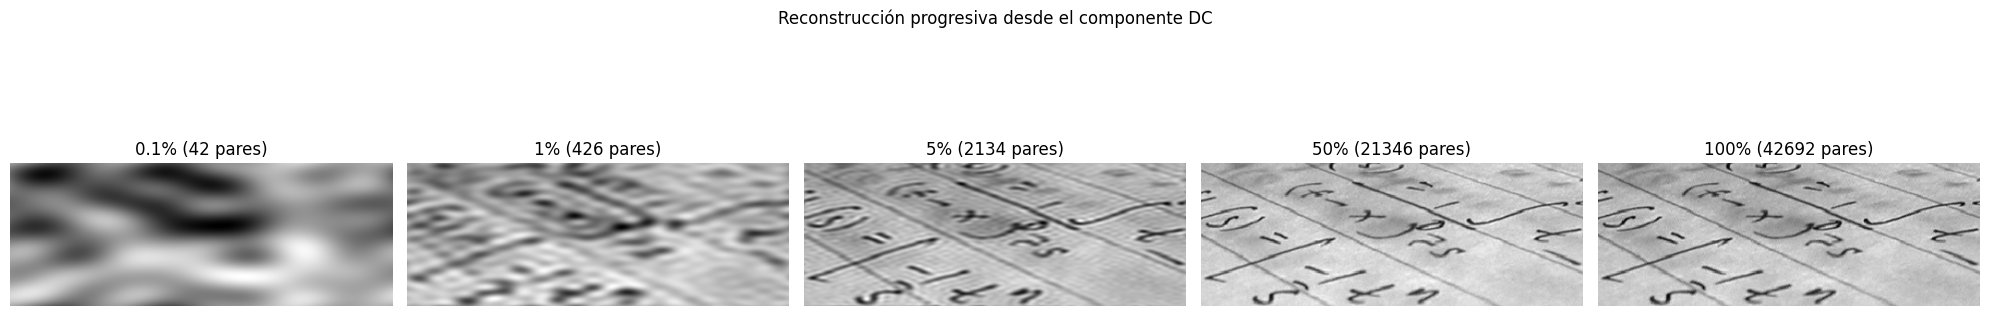

In [ ]:
porcentajes = [0.1, 1, 5, 50, 100]
reconstruir_imagenes(F_Shift_baja, datos_baja, porcentajes)
reconstruir_imagenes(F_Shift_media, datos_media, porcentajes)
reconstruir_imagenes(F_Shift_alta, datos_alta, porcentajes)

#### Calcula el número de coeficientes requerido para llegar a un error del 20%, del 10% y del 5% en términos de NRMSE (Normalized Root Mean Squared Error) y analiza cómo el número de coeficientes cambia dependiendo de la imagen que utilices.

In [ ]:
# @title Funciones
def error_nrmse(img, F_shifted, par_puntos, paso=1):
    #Variables
    M, N = F_shifted.shape
    rango = img.max() - img.min()
    F_parcial = np.zeros((M, N), dtype=np.complex128)
    historial = []

    # Punto inicial: 0 coeficientes
    rmse_0 = np.sqrt(np.mean(img.astype(float) ** 2))
    historial.append((0, rmse_0 / rango))

    for k, par in enumerate(par_puntos):
        i,  j  = par['pos_1']
        si, sj = par['pos_2']
        F_parcial[i,  j]  = par['coef_1']
        F_parcial[si, sj] = par['coef_2']

        if (k + 1) % paso == 0 or (k + 1) == len(par_puntos):
            imagen_rec = np.real(np.fft.ifft2(np.fft.ifftshift(F_parcial)))
            rmse   = np.sqrt(np.mean((img.astype(float) - imagen_rec) ** 2))
            nrmse = rmse / rango
            historial.append((k + 1, nrmse))

    return historial


def encontrar_umbrales(historial, por_error):
    resultados = {}
    total = historial[-1][0]  # total de pares de puntos

    for n_pares, nrmse in historial:
        for umbral in por_error:
            if umbral not in resultados and nrmse <= umbral:
                resultados[umbral] = {
                    'n_pares'    : n_pares,
                    'porcentaje' : round(100 * n_pares / total, 2),
                    'nrmse'      : round(nrmse, 6),
                }
        if len(resultados) == len(por_error):
            break

    return resultados


def graficar_nrmse(historial, resultados, por_error):
    n_vals    = [h[0] for h in historial]
    nrmse_vals = [h[1] for h in historial]

    plt.figure(figsize=(10, 5))
    plt.plot(n_vals, nrmse_vals, color='steelblue', linewidth=1.5, label='NRMSE')

    colores = {0.20: 'green', 0.10: 'orange', 0.05: 'red'}

    for umbral in por_error:
        color = colores.get(umbral, 'gray')

        # Línea horizontal del umbral
        plt.axhline(y=umbral, color=color, linestyle='--',
                    linewidth=1, label=f'Umbral {umbral*100:.0f}%')

        # Marcar el punto donde se alcanza
        if umbral in resultados:
            info = resultados[umbral]
            plt.axvline(x=info['n_pares'], color=color, linestyle=':', linewidth=1)

    plt.xlabel('Número de pares de coeficientes acumulados')
    plt.ylabel('NRMSE')
    plt.title('Errores en la aproximaciones de Fourier')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

NRMSE ≤ 5%  →  1 pares  (0.0%)
NRMSE ≤ 10%  →  0 pares  (0.0%)
NRMSE ≤ 20%  →  0 pares  (0.0%)


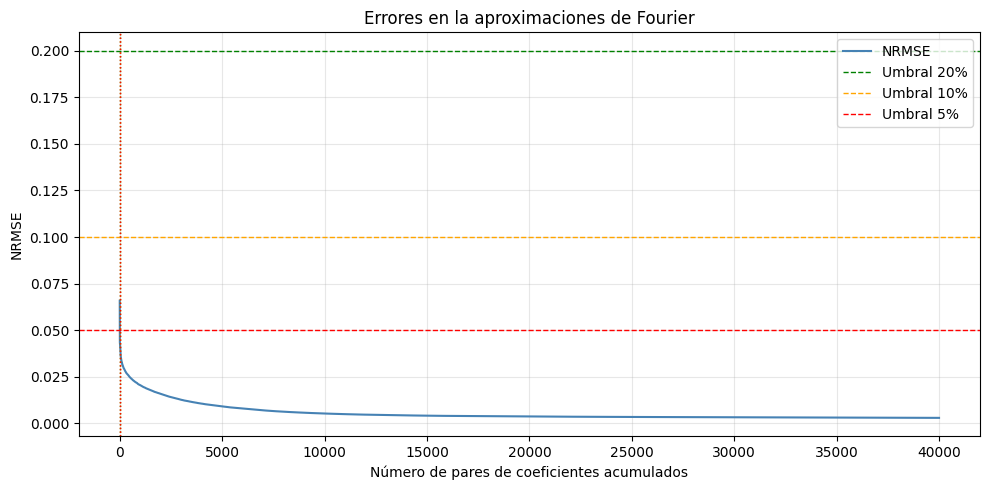

In [ ]:
# @title imagen de baja frecuencia
por_error = [0.20, 0.10, 0.05]

historial  = error_nrmse(img_baja, F_Shift_baja, datos_baja[:40000])
resultados = encontrar_umbrales(historial, por_error)

for umbral, info in sorted(resultados.items()):
    print(f"NRMSE ≤ {umbral*100:.0f}%  →  {info['n_pares']} pares  ({info['porcentaje']}%)")

graficar_nrmse(historial, resultados, por_error)

In [ ]:
# @title Verificacion del NRMSE inicial (0 coeficientes)
print(f"NRMSE inicial (0 coefs): {historial[0][1]:.6f}")
print(f"NRMSE inicial (%):       {historial[0][1]*100:.2f}%")

print("\nPrimeros puntos del historial:")
for n_pares, nrmse in historial[:5]:
    print(f"  {n_pares} pares → NRMSE = {nrmse*100:.4f}%")

NRMSE inicial (0 coefs): 0.065849
NRMSE inicial (%):       6.58%

Primeros puntos del historial:
  0 pares → NRMSE = 6.5849%
  1 pares → NRMSE = 4.5578%
  2 pares → NRMSE = 4.4249%
  3 pares → NRMSE = 4.4198%
  4 pares → NRMSE = 4.3989%


NRMSE ≤ 5%  →  4489 pares  (11.22%)
NRMSE ≤ 10%  →  317 pares  (0.79%)
NRMSE ≤ 20%  →  24 pares  (0.06%)


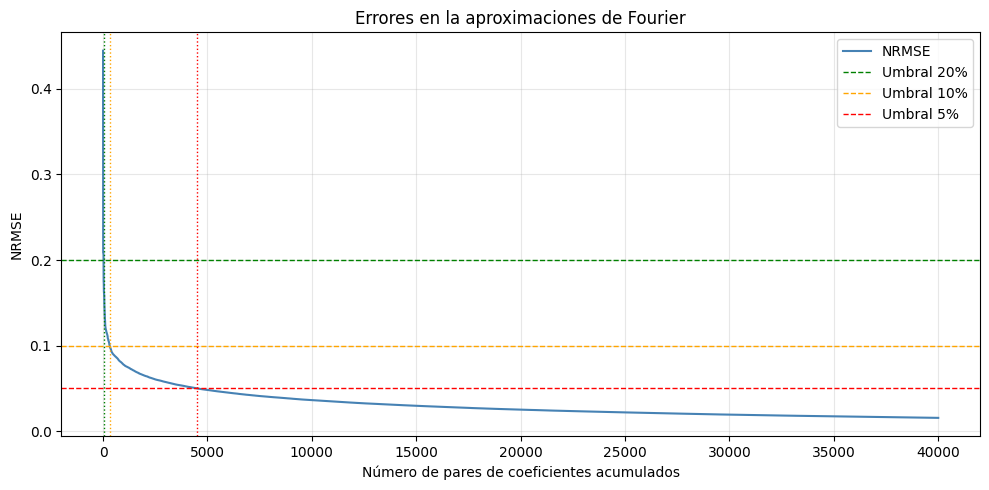

In [105]:
# @title imagen de media frecuencia
por_error = [0.20, 0.10, 0.05]

historial  = error_nrmse(img_media, F_Shift_media, datos_media[:40000])
resultados = encontrar_umbrales(historial, por_error)

for umbral, info in sorted(resultados.items()):
    print(f"NRMSE ≤ {umbral*100:.0f}%  →  {info['n_pares']} pares  ({info['porcentaje']}%)")

graficar_nrmse(historial, resultados, por_error)

NRMSE ≤ 5%  →  1892 pares  (4.73%)
NRMSE ≤ 10%  →  176 pares  (0.44%)
NRMSE ≤ 20%  →  1 pares  (0.0%)


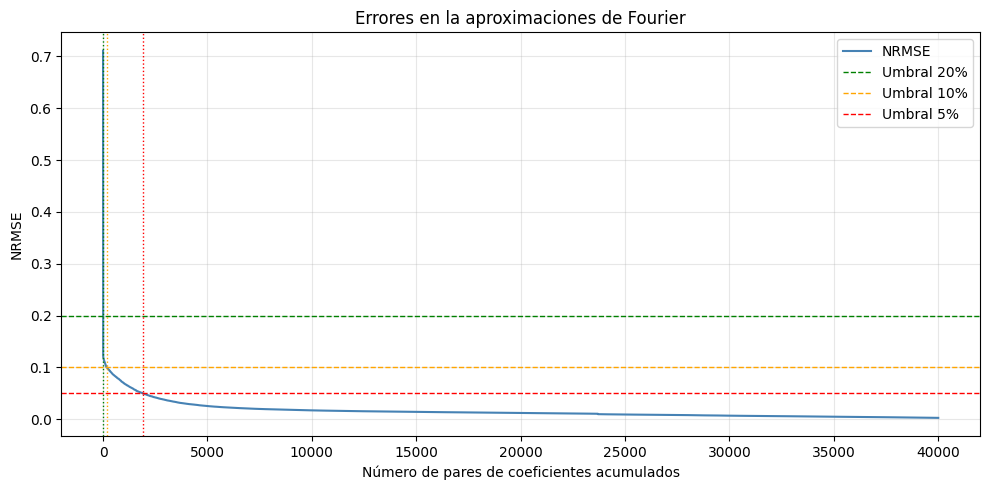

In [108]:
# @title imagen de alta frecuencia
por_error = [0.20, 0.10, 0.05]

historial  = error_nrmse(img_alta, F_Shift_alta, datos_alta[:40000])
resultados = encontrar_umbrales(historial, por_error)

for umbral, info in sorted(resultados.items()):
    print(f"NRMSE ≤ {umbral*100:.0f}%  →  {info['n_pares']} pares  ({info['porcentaje']}%)")

graficar_nrmse(historial, resultados, por_error)

In [109]:
# @title Verificacion del NRMSE inicial (0 coeficientes)
print(f"NRMSE inicial (0 coefs): {historial[0][1]:.6f}")
print(f"NRMSE inicial (%):       {historial[0][1]*100:.2f}%")

print("\nPrimeros puntos del historial:")
for n_pares, nrmse in historial[:5]:
    print(f"  {n_pares} pares → NRMSE = {nrmse*100:.4f}%")

NRMSE inicial (0 coefs): 0.711000
NRMSE inicial (%):       71.10%

Primeros puntos del historial:
  0 pares → NRMSE = 71.1000%
  1 pares → NRMSE = 13.2325%
  2 pares → NRMSE = 12.6029%
  3 pares → NRMSE = 12.4219%
  4 pares → NRMSE = 12.4123%
